# How are in-demand skills for Data Scientist

**Methology**
1. Aggregate Skill count monthly
2. Re-analyze base on percentage of total job
3. Plot the monthly  skill demand


In [129]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# loading Data 
from datasets import  load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
# cleaning data 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [130]:
df_US_DS = df[(df['job_country'] == "United States") &(df['job_title_short'] == 'Data Scientist') ].copy()

In [131]:
df_US_DS['job_posted_month_no'] = df_US_DS['job_posted_date'].dt.month

In [132]:
df_US_DS_eploded = df_US_DS.explode('job_skills')

In [133]:
import calendar

In [134]:
df_US_DS_pivot = df_US_DS_eploded.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)


In [135]:
df_US_DS_pivot.loc['total'] = df_US_DS_pivot.sum()

In [136]:
df_US_DS_pivot = df_US_DS_pivot[df_US_DS_pivot.loc['total'].sort_values(ascending = False).index]

In [137]:
df_US_DS_pivot = df_US_DS_pivot.drop('total')

In [138]:
df_US_totals = df_US_DS.groupby('job_posted_month_no').size()
df_US_totals

job_posted_month_no
1     6915
2     4956
3     4779
4     4867
5     4377
6     4645
7     4876
8     6318
9     4568
10    4882
11    4175
12    3472
dtype: int64

In [139]:
df_US_DS_perc = df_US_DS_pivot.div(df_US_totals/100,axis=0)

In [140]:
df_US_DS_perc=df_US_DS_perc.reset_index()
# df_US_DS_perc=df_US_DS_perc.set_index("job_posted_month_no")

In [143]:
df_US_DS_perc

job_skills,job_posted_month_no,python,sql,r,sas,tableau,aws,spark,java,tensorflow,...,fedora,mattermost,nuix,asp.net core,shogun,clickup,ocaml,wrike,symfony,couchdb
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,1,75.820680,54.519161,48.618944,24.584237,23.571945,19.725235,19.609544,13.246565,12.957339,...,0.000000,0.000000,0.014461,0.014461,0.000000,0.014461,0.000000,0.000000,0.014461,0.014461
Feb,2,75.020178,53.874092,47.094431,23.083132,25.585149,17.231638,18.058918,13.014528,11.400323,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,3,71.019042,50.763758,45.804562,23.938062,23.561415,17.744298,16.467880,12.031806,11.069261,...,0.000000,0.000000,0.000000,0.000000,0.020925,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,4,74.419560,50.606123,44.811999,24.738032,24.922950,18.122046,16.909801,12.779947,11.958085,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,5,73.840530,52.387480,46.058944,26.273703,26.822024,18.208819,17.683345,14.370573,11.811743,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,6,73.864370,52.572659,45.360603,24.930032,24.434876,17.610334,17.696448,12.615716,11.560818,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021529,0.000000,0.000000
Jul,7,72.621001,50.840853,45.324036,22.682527,25.082034,17.637408,16.447908,11.915505,11.689910,...,0.020509,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,8,72.269706,52.611586,45.837290,25.292814,24.058246,17.030706,17.014878,12.139918,12.804685,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,9,68.126095,47.176007,39.207531,25.350263,20.161996,15.258319,16.199650,11.690018,12.412434,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [144]:

df_US_DS_perc['job_posted_month'] = df_US_DS_perc['job_posted_month_no'].apply(lambda x :pd.to_datetime(x,format='%m').strftime('%b'))
df_US_DS_perc = df_US_DS_perc.set_index('job_posted_month')
df_US_DS_perc = df_US_DS_perc.drop(columns='job_posted_month_no')

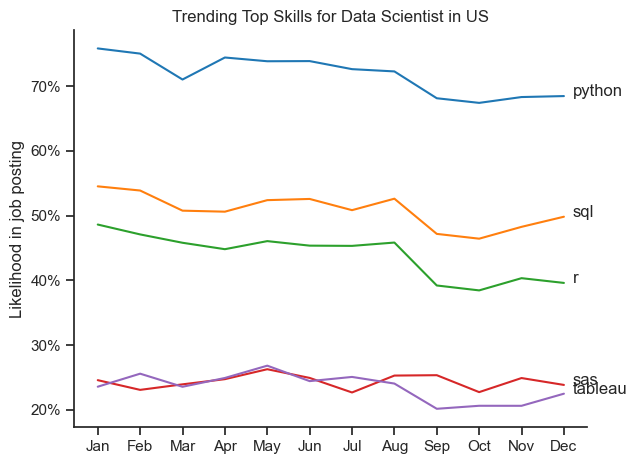

In [164]:
from matplotlib.ticker  import PercentFormatter
df_plot = df_US_DS_perc.iloc[:,:5]
sns.set_theme(style='ticks')
sns.lineplot(data=df_plot,dashes=False,palette="tab10" )
sns.despine()

plt.title("Trending Top Skills for Data Scientist in US")
plt.xlabel("")
plt.ylabel('Likelihood in job posting')
plt.legend().remove()
for i in range(5):
    plt.text(11.2,df_plot.iloc[-1,i],df_plot.columns[i])
plt.tight_layout()
ax = plt.gca()
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pro:f"{int(y)}%"))
ax.yaxis.set_major_formatter(PercentFormatter())